In [1]:
#IMPORT LIBRARIES 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#import libraries for Linear Regresrion
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
#LOAD FILES
file_route = 'Final_Table.csv'
df = pd.read_csv(file_route)

#df.head()

In [3]:
#CONVERT DATA TO NUMERICAL FORMAT
df['DATE'] = pd.to_datetime(df['DATE'])
df['DATE'] = df['DATE'].astype('int64')

#df.head()

In [4]:
#EXTRACT FEATURES AND TARGET VARIABLES
X = df[['DATE','DAY', 'WEEK_DAY', 'MONTH','YEAR', 'HOLIDAY', 'PRE_HOLIDAY', 'LAST_WEEK_TOTAL']]
y = df[['TOTAL']]

In [5]:
#SPLIT DATA IN TRAINING AND TESTING
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=66)

In [6]:
#BUILD LINEAR REGRESSION MODEL
model = LinearRegression()

In [7]:
# check X_test
#X_test

In [8]:
#TRAIN MODEL
model.fit(X_train, y_train)

LinearRegression()

In [9]:
#EVALUATE MODEL
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-Squared: {r2}")

Mean Squared Error: 1119977.3064038777
R-Squared: -0.0161952631957214


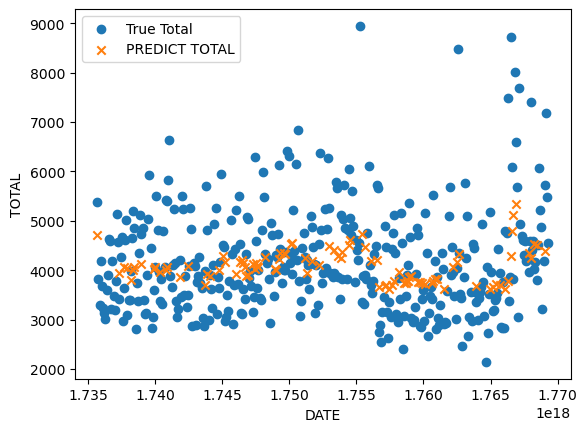

In [10]:
#CREATE GRAPH AND VISUALIZATION
plt.scatter(df['DATE'],df['TOTAL'], label="True Total")
plt.scatter(X_test['DATE'], y_pred, label='PREDICT TOTAL', marker='x')
plt.xlabel('DATE')
plt.ylabel('TOTAL')
plt.legend()
plt.show()

In [11]:
predict_test = pd.DataFrame({'DATE': ['1/26/2026', '1/27/2026','1/28/2026', '1/29/2026','1/30/2026', '1/31/2026','2/1/2026'],
                            'DAY': [26,27,28,29,30,31,1],
                            'WEEK_DAY': [2,3,4,5,6,7,1],
                            'MONTH': [1,1,1,1,1,1,2],
                            'YEAR': [2026, 2026, 2026, 2026, 2026, 2026, 2026],
                            'HOLIDAY': [0,0,0,0,0,0,0],
                            'PRE_HOLIDAY': [0,0,0,0,0,0,0],
                            'LAST_WEEK_TOTAL': [30940,30210,30800,31130,30000,32950,32872]})
#predict_test

In [12]:
#CONVERT DATA TO NUMERICAL FORMAT
predict_test['DATE'] = pd.to_datetime(predict_test['DATE'])
predict_test['DATE'] = predict_test['DATE'].astype('int64')


In [13]:
y_pred = model.predict(predict_test)

In [14]:
y_pred

array([[4295.3447502 ],
       [4221.7897829 ],
       [4281.3073438 ],
       [4314.61364915],
       [4200.73367331],
       [4498.16878463],
       [4490.34371818]])